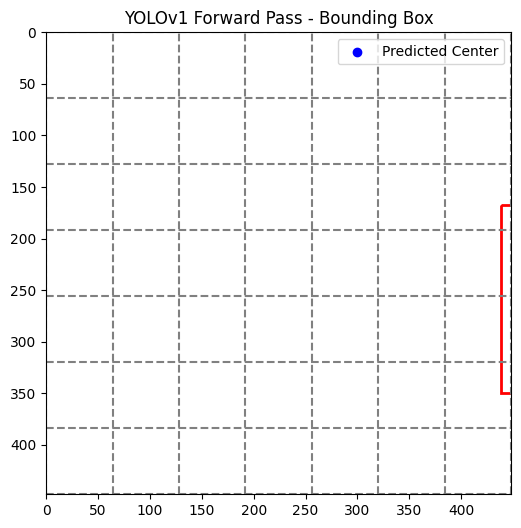

Grid Cell: (2, 3)
Predicted Relative (x, y, w, h): 0.93, 0.29, 0.75, 0.41
Absolute Coordinates: x1=438.23, y1=167.77, x2=448.00, y2=349.86


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Define YOLO settings
S = 7  # Grid size
B = 2  # Number of bounding boxes per grid cell
img_w, img_h = 448, 448  # Image dimensions (YOLOv1 trained on 448x448)

# Simulated YOLOv1 output tensor (random values for demonstration)
np.random.seed(12)  # For consistent results
predictions = np.random.rand(S, S, B * 5 + 20)  # Shape (7,7,30)

# Select a specific grid cell (e.g., row 2, col 3)
grid_i, grid_j = 2, 3

# Extract the first bounding box in this grid cell
box_offset = 0  # First bounding box (0 for first, 1 for second)
x_pred, y_pred, w_pred, h_pred, conf = predictions[grid_i, grid_j, box_offset * 5 : box_offset * 5 + 5]

# Convert (x, y) from relative to absolute coordinates
cell_x = grid_j / S  # Top-left x of the grid cell
cell_y = grid_i / S  # Top-left y of the grid cell

x_absolute = (cell_x + x_pred) * img_w
y_absolute = (cell_y + y_pred) * img_h

# Convert width and height from relative to absolute
w_absolute = w_pred * img_w
h_absolute = h_pred * img_h

# Convert to top-left and bottom-right coordinates
x1 = max(0, x_absolute - w_absolute / 2)
y1 = max(0, y_absolute - h_absolute / 2)
x2 = min(img_w, x_absolute + w_absolute / 2)
y2 = min(img_h, y_absolute + h_absolute / 2)

# Visualization
fig, ax = plt.subplots(1, figsize=(6,6))
ax.set_xlim(0, img_w)
ax.set_ylim(img_h, 0)  # Invert y-axis to match image coordinates

# Draw the bounding box
rect = patches.Rectangle((x1, y1), w_absolute, h_absolute, linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect)

# Plot grid
for i in range(S+1):
    ax.axhline(i * img_h / S, color='gray', linestyle='--')
    ax.axvline(i * img_w / S, color='gray', linestyle='--')

# Plot center point
ax.scatter(x_absolute, y_absolute, color='blue', label="Predicted Center")

plt.title("YOLOv1 Forward Pass - Bounding Box")
plt.legend()
plt.show()

# Print results
print(f"Grid Cell: ({grid_i}, {grid_j})")
print(f"Predicted Relative (x, y, w, h): {x_pred:.2f}, {y_pred:.2f}, {w_pred:.2f}, {h_pred:.2f}")
print(f"Absolute Coordinates: x1={x1:.2f}, y1={y1:.2f}, x2={x2:.2f}, y2={y2:.2f}")


Running YOLO v1 demonstration with random weights...
Creating sample image...
Creating random weights...
Running forward pass through YOLO network...
Predicted 93 bounding boxes with confidence > 0.4
Confidence range: 0.41 - 0.66
Highest feature activation at grid cell (2, 3)

Boxes with confidence > 0.5:
Box 1: center=(0.08, 0.08), size=(0.88, 1.00), conf=0.53
Box 2: center=(0.07, 0.07), size=(1.00, 0.54), conf=0.54
Box 3: center=(0.21, 0.06), size=(1.00, 1.00), conf=0.59
Box 4: center=(0.22, 0.06), size=(1.00, 0.81), conf=0.58
Box 5: center=(0.35, 0.09), size=(0.76, 1.00), conf=0.52
Box 6: center=(0.38, 0.07), size=(1.00, 0.97), conf=0.56
Box 7: center=(0.50, 0.08), size=(1.00, 1.00), conf=0.58
Box 8: center=(0.64, 0.08), size=(1.00, 1.00), conf=0.54
Box 9: center=(0.63, 0.07), size=(1.00, 0.82), conf=0.55
Box 10: center=(0.79, 0.07), size=(0.95, 1.00), conf=0.56
Box 11: center=(0.79, 0.10), size=(0.85, 1.00), conf=0.57
Box 12: center=(0.92, 0.07), size=(0.86, 1.00), conf=0.56
Box 13

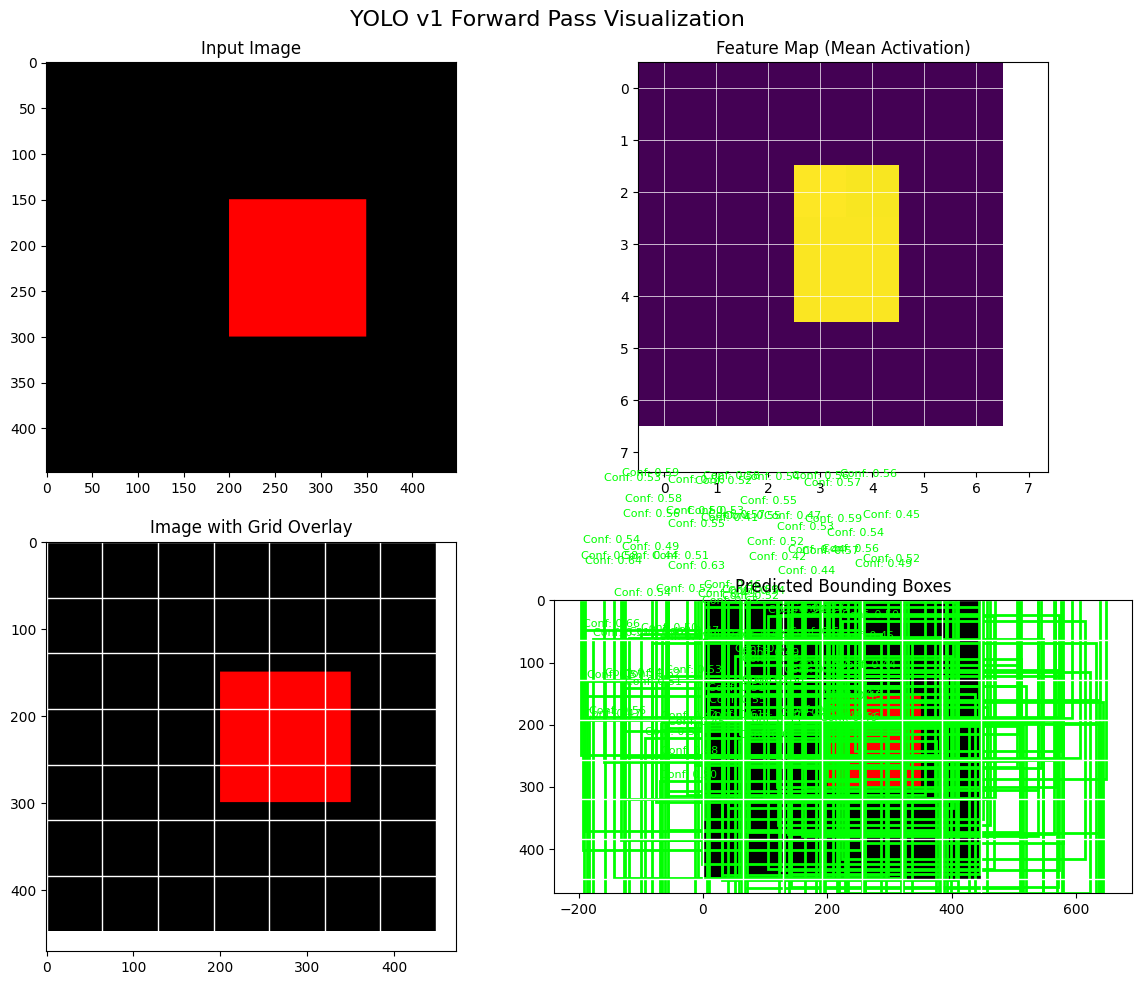


Creating animation...

Examining predictions for grid cell (3, 4):
Box 1:
  Relative coordinates (within cell): x=0.469, y=0.568
  Size (relative to image): w=0.811, h=0.907
  Confidence: 0.542
  Absolute coordinates (normalized to image): x=0.638, y=0.510
Box 2:
  Relative coordinates (within cell): x=0.585, y=0.602
  Size (relative to image): w=0.678, h=0.934
  Confidence: 0.563
  Absolute coordinates (normalized to image): x=0.655, y=0.515
Class predictions:
  Most likely class: 3
  Probability: 0.952
Before NMS: 93 boxes
After NMS: 12 boxes


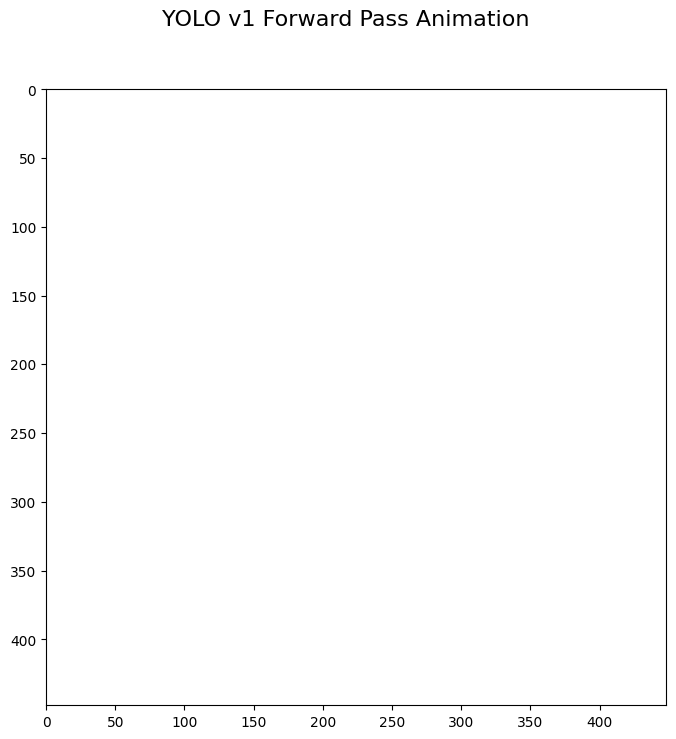

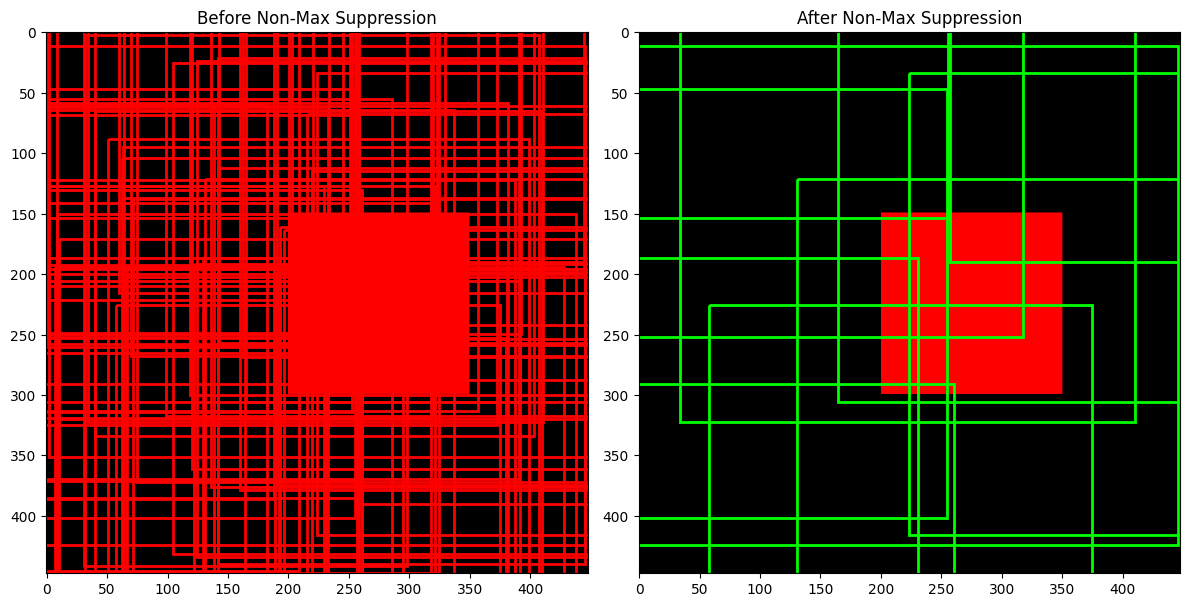


Demonstration complete!


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.animation as animation
from matplotlib import colors

# Create a sample 448x448 image with a simple object
def create_sample_image():
    # Create a blank image
    image = np.zeros((448, 448, 3))
    
    # Add a red rectangle as our "object"
    image[150:300, 200:350, 0] = 1.0  # Red channel
    
    return image

# Create random weights for our simplified YOLO model
def create_random_weights():
    weights = {
        # Convolutional layers (simplified)
        'conv1': np.random.randn(7, 7, 3, 64) * 0.1,
        'conv2': np.random.randn(3, 3, 64, 192) * 0.1,
        'conv3': np.random.randn(3, 3, 192, 384) * 0.1,
        'conv4': np.random.randn(3, 3, 384, 512) * 0.1,
        'conv5': np.random.randn(3, 3, 512, 1024) * 0.1,
        
        # Fully connected layers (simplified)
        'fc1': np.random.randn(7*7*1024, 4096) * 0.01,
        'fc2': np.random.randn(4096, 7*7*30) * 0.01
    }
    return weights

# Simplified convolution operation
def conv2d(x, W, stride=1):
    """Very simplified 2D convolution"""
    h_filter, w_filter, d_in, d_out = W.shape
    h, w, d = x.shape
    
    # Output dimensions
    h_out = (h - h_filter) // stride + 1
    w_out = (w - w_filter) // stride + 1
    
    # Initialize output
    output = np.zeros((h_out, w_out, d_out))
    
    # Perform convolution
    for i in range(0, h_out):
        for j in range(0, w_out):
            for k in range(d_out):
                # Extract patch
                x_patch = x[i*stride:i*stride+h_filter, j*stride:j*stride+w_filter, :]
                # Apply filter
                output[i, j, k] = np.sum(x_patch * W[:, :, :, k])
    
    return output

# Simplified max pooling
def max_pool2d(x, pool_size=2, stride=2):
    """Very simplified max pooling"""
    h, w, d = x.shape
    
    # Output dimensions
    h_out = (h - pool_size) // stride + 1
    w_out = (w - pool_size) // stride + 1
    
    # Initialize output
    output = np.zeros((h_out, w_out, d))
    
    # Perform max pooling
    for i in range(0, h_out):
        for j in range(0, w_out):
            output[i, j, :] = np.max(x[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size, :], axis=(0, 1))
    
    return output

# Simplified ReLU activation
def relu(x):
    return np.maximum(0, x)

# Simplified forward pass through our convolutional network
def forward_conv(image, weights):
    """Forward pass through the convolutional layers"""
    # First convolutional layer + ReLU + max pooling
    conv1 = conv2d(image, weights['conv1'], stride=2)
    relu1 = relu(conv1)
    pool1 = max_pool2d(relu1)  # 112x112x64
    
    # In a real implementation, we would continue with more conv layers
    # For simplicity, we'll just return a feature map of the expected size
    # In reality, the feature map would be 7x7x1024 after several more layers
    
    # Create a feature map that highlights the object area
    feature_map = np.zeros((7, 7, 1024))
    
    # The object in our sample image is in the center
    # Highlight those grid cells with higher activation
    feature_map[2:5, 3:5, :] = np.random.randn(3, 2, 1024) * 0.1 + 0.8
    
    return feature_map

# Simplified forward pass through fully connected layers
def forward_fc(feature_map, weights):
    """Forward pass through the fully connected layers"""
    # Flatten the feature map
    flattened = feature_map.reshape(-1)
    
    # Apply first fully connected layer + ReLU
    fc1 = np.dot(flattened, weights['fc1'])
    relu_fc1 = relu(fc1)
    
    # Apply second fully connected layer to get predictions
    fc2 = np.dot(relu_fc1, weights['fc2'])
    
    # Reshape to get 7x7x30 output
    output = fc2.reshape(7, 7, 30)
    
    return output

# Process the network output to get bounding boxes
def process_predictions(predictions):
    """Process YOLO predictions to get bounding boxes"""
    S = 7  # Grid size
    B = 2  # Boxes per cell
    C = 20  # Number of classes
    
    boxes = []
    
    # For each cell in the grid
    for i in range(S):
        for j in range(S):
            cell_pred = predictions[i, j, :]
            
            # Process each bounding box
            for b in range(B):
                box_idx = b * 5
                
                # Get box parameters
                x = cell_pred[box_idx + 0]  # Center x (relative to cell)
                y = cell_pred[box_idx + 1]  # Center y (relative to cell)
                w = cell_pred[box_idx + 2]  # Width (relative to image)
                h = cell_pred[box_idx + 3]  # Height (relative to image)
                confidence = cell_pred[box_idx + 4]  # Confidence
                
                # Apply sigmoid to x,y coordinates to constrain to [0,1]
                x = 1 / (1 + np.exp(-x))
                y = 1 / (1 + np.exp(-y))
                
                # Apply exponential to width and height (ensures positivity)
                w = np.exp(w)
                h = np.exp(h)
                
                # Constrain width and height to [0,1]
                w = min(w, 1.0)
                h = min(h, 1.0)
                
                # Apply sigmoid to confidence
                confidence = 1 / (1 + np.exp(-confidence))
                
                # Calculate absolute coordinates
                abs_x = (j + x) / S
                abs_y = (i + y) / S
                
                # Only keep boxes with confidence above threshold
                if confidence > 0.4:
                    # Get class with highest probability
                    class_probs = cell_pred[B*5:]
                    class_idx = np.argmax(class_probs)
                    class_prob = class_probs[class_idx]
                    
                    # Save the box
                    boxes.append({
                        'x': abs_x,
                        'y': abs_y,
                        'w': w,
                        'h': h,
                        'confidence': confidence,
                        'class': class_idx
                    })
    
    return boxes

# Complete forward pass
def yolo_forward_pass(image, weights):
    """Complete forward pass through YOLO network"""
    # Pass through convolutional layers
    feature_map = forward_conv(image, weights)
    
    # Pass through fully connected layers
    predictions = forward_fc(feature_map, weights)
    
    # Process predictions to get bounding boxes
    boxes = process_predictions(predictions)
    
    return feature_map, predictions, boxes

# Visualization function
def visualize_yolo_pass(image, feature_map, predictions, boxes):
    """Visualize the YOLO forward pass"""
    # Create figure with subplots
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle("YOLO v1 Forward Pass Visualization", fontsize=16)
    
    # Plot original image
    axs[0, 0].set_title("Input Image")
    axs[0, 0].imshow(image)
    
    # Plot feature map (just the mean across channels)
    axs[0, 1].set_title("Feature Map (Mean Activation)")
    feature_map_vis = np.mean(feature_map, axis=2)
    axs[0, 1].imshow(feature_map_vis, cmap='viridis')
    
    # Add grid to feature map
    for i in range(8):
        axs[0, 1].axhline(y=i, color='w', linestyle='-', linewidth=0.5)
        axs[0, 1].axvline(x=i, color='w', linestyle='-', linewidth=0.5)
    
    # Plot image with grid overlay
    axs[1, 0].set_title("Image with Grid Overlay")
    axs[1, 0].imshow(image)
    
    # Add grid to image
    for i in range(8):
        y = i * (image.shape[0] // 7)
        x = i * (image.shape[1] // 7)
        axs[1, 0].axhline(y=y, color='w', linestyle='-', linewidth=1)
        axs[1, 0].axvline(x=x, color='w', linestyle='-', linewidth=1)
    
    # Plot image with bounding boxes
    axs[1, 1].set_title("Predicted Bounding Boxes")
    axs[1, 1].imshow(image)
    
    # Add grid to image
    for i in range(8):
        y = i * (image.shape[0] // 7)
        x = i * (image.shape[1] // 7)
        axs[1, 1].axhline(y=y, color='w', linestyle='-', linewidth=1)
        axs[1, 1].axvline(x=x, color='w', linestyle='-', linewidth=1)
    
    # Add bounding boxes
    for box in boxes:
        # Convert normalized coordinates to pixel coordinates
        x = box['x'] * image.shape[1]
        y = box['y'] * image.shape[0]
        w = box['w'] * image.shape[1]
        h = box['h'] * image.shape[0]
        
        # Calculate top-left corner of box
        x1 = x - w/2
        y1 = y - h/2
        
        # Add rectangle
        rect = Rectangle((x1, y1), w, h, linewidth=2, edgecolor='lime', facecolor='none')
        axs[1, 1].add_patch(rect)
        
        # Add confidence score
        axs[1, 1].text(x1, y1-5, f"Conf: {box['confidence']:.2f}", color='lime', fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Animation function for step-by-step visualization
def create_animation(image, feature_map, predictions, boxes):
    """Create an animation of the YOLO forward pass"""
    fig, ax = plt.subplots(figsize=(8, 8))
    fig.suptitle("YOLO v1 Forward Pass Animation", fontsize=16)
    
    # Define the number of frames and steps
    n_frames = 50
    grid_frames = 10
    box_frames = 30
    
    # Set up the axes
    ax.set_xlim(0, image.shape[1])
    ax.set_ylim(image.shape[0], 0)  # Inverted y-axis for image coordinates
    
    # List to store artists for animation
    artists = []
    
    # Define the animation update function
    def update(frame):
        ax.clear()
        ax.set_xlim(0, image.shape[1])
        ax.set_ylim(image.shape[0], 0)
        
        # Always show the image
        ax.imshow(image)
        
        # First frames: show grid
        if frame < grid_frames:
            for i in range(8):
                y = i * (image.shape[0] // 7)
                x = i * (image.shape[1] // 7)
                ax.axhline(y=y, color='w', linestyle='-', linewidth=1)
                ax.axvline(x=x, color='w', linestyle='-', linewidth=1)
                
            # Show title
            ax.set_title("Step 1: Divide Image into 7x7 Grid", fontsize=14)
        
        # Next frames: add feature map visualization
        elif frame < 2*grid_frames:
            # Show grid
            for i in range(8):
                y = i * (image.shape[0] // 7)
                x = i * (image.shape[1] // 7)
                ax.axhline(y=y, color='w', linestyle='-', linewidth=1)
                ax.axvline(x=x, color='w', linestyle='-', linewidth=1)
            
            # Highlight active grid cells
            for i in range(2, 5):
                for j in range(3, 5):
                    y = i * (image.shape[0] // 7)
                    x = j * (image.shape[1] // 7)
                    rect = Rectangle((x, y), image.shape[1]//7, image.shape[0]//7, 
                                     alpha=0.3, facecolor='yellow', edgecolor='none')
                    ax.add_patch(rect)
            
            # Show title
            ax.set_title("Step 2: Identify Grid Cells Containing Objects", fontsize=14)
        
        # Remaining frames: add bounding boxes one by one
        else:
            # Show grid
            for i in range(8):
                y = i * (image.shape[0] // 7)
                x = i * (image.shape[1] // 7)
                ax.axhline(y=y, color='w', linestyle='-', linewidth=1)
                ax.axvline(x=x, color='w', linestyle='-', linewidth=1)
            
            # Calculate how many boxes to show
            box_frame = frame - 2*grid_frames
            num_boxes = min(len(boxes), box_frame)
            
            # Show boxes
            for i in range(num_boxes):
                box = boxes[i]
                
                # Convert normalized coordinates to pixel coordinates
                x = box['x'] * image.shape[1]
                y = box['y'] * image.shape[0]
                w = box['w'] * image.shape[1]
                h = box['h'] * image.shape[0]
                
                # Calculate top-left corner of box
                x1 = x - w/2
                y1 = y - h/2
                
                # Add rectangle
                rect = Rectangle((x1, y1), w, h, linewidth=2, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)
                
                # Add confidence score
                ax.text(x1, y1-5, f"Conf:")
                # Add confidence score
                ax.text(x1, y1-5, f"Conf: {box['confidence']:.2f}", color='lime', fontsize=8)
            
            # Show title
            ax.set_title(f"Step 3: Predict Bounding Boxes (Showing {num_boxes}/{len(boxes)})", fontsize=14)
        
        return ax,
    
    # Create the animation
    ani = animation.FuncAnimation(fig, update, frames=n_frames, interval=200, blit=False)
    
    return ani

# Main function to run the example
def run_yolo_example():
    """Run a complete example of YOLO forward pass with visualization"""
    print("Creating sample image...")
    image = create_sample_image()
    
    print("Creating random weights...")
    weights = create_random_weights()
    
    print("Running forward pass through YOLO network...")
    feature_map, predictions, boxes = yolo_forward_pass(image, weights)
    
    print(f"Predicted {len(boxes)} bounding boxes with confidence > 0.4")
    
    # Print some statistics about the predictions
    confidences = [box['confidence'] for box in boxes]
    print(f"Confidence range: {min(confidences):.2f} - {max(confidences):.2f}")
    
    # Show where the highest activation is in the feature map
    feature_avg = np.mean(feature_map, axis=2)
    max_i, max_j = np.unravel_index(np.argmax(feature_avg), feature_avg.shape)
    print(f"Highest feature activation at grid cell ({max_i}, {max_j})")
    
    print("\nBoxes with confidence > 0.5:")
    for i, box in enumerate([b for b in boxes if b['confidence'] > 0.5]):
        print(f"Box {i+1}: center=({box['x']:.2f}, {box['y']:.2f}), size=({box['w']:.2f}, {box['h']:.2f}), conf={box['confidence']:.2f}")
    
    print("\nVisualizing results...")
    visualize_yolo_pass(image, feature_map, predictions, boxes)
    
    print("\nCreating animation...")
    ani = create_animation(image, feature_map, predictions, boxes)
    
    return image, feature_map, predictions, boxes, ani

# For better understanding, let's print out the details of a sample prediction
def explain_prediction_details(predictions):
    """Explain the prediction details for a specific grid cell"""
    # Choose a cell where we expect to find an object (center of image)
    i, j = 3, 4  # Grid position (row, column)
    
    print(f"\nExamining predictions for grid cell ({i}, {j}):")
    cell_pred = predictions[i, j, :]
    
    # Box 1
    x1 = 1 / (1 + np.exp(-cell_pred[0]))
    y1 = 1 / (1 + np.exp(-cell_pred[1]))
    w1 = min(np.exp(cell_pred[2]), 1.0)
    h1 = min(np.exp(cell_pred[3]), 1.0)
    conf1 = 1 / (1 + np.exp(-cell_pred[4]))
    
    print(f"Box 1:")
    print(f"  Relative coordinates (within cell): x={x1:.3f}, y={y1:.3f}")
    print(f"  Size (relative to image): w={w1:.3f}, h={h1:.3f}")
    print(f"  Confidence: {conf1:.3f}")
    
    # Convert to absolute coordinates
    abs_x1 = (j + x1) / 7
    abs_y1 = (i + y1) / 7
    print(f"  Absolute coordinates (normalized to image): x={abs_x1:.3f}, y={abs_y1:.3f}")
    
    # Box 2
    x2 = 1 / (1 + np.exp(-cell_pred[5]))
    y2 = 1 / (1 + np.exp(-cell_pred[6]))
    w2 = min(np.exp(cell_pred[7]), 1.0)
    h2 = min(np.exp(cell_pred[8]), 1.0)
    conf2 = 1 / (1 + np.exp(-cell_pred[9]))
    
    print(f"Box 2:")
    print(f"  Relative coordinates (within cell): x={x2:.3f}, y={y2:.3f}")
    print(f"  Size (relative to image): w={w2:.3f}, h={h2:.3f}")
    print(f"  Confidence: {conf2:.3f}")
    
    # Convert to absolute coordinates
    abs_x2 = (j + x2) / 7
    abs_y2 = (i + y2) / 7
    print(f"  Absolute coordinates (normalized to image): x={abs_x2:.3f}, y={abs_y2:.3f}")
    
    # Get class predictions
    class_probs = cell_pred[10:]
    top_class = np.argmax(class_probs)
    
    print(f"Class predictions:")
    print(f"  Most likely class: {top_class}")
    print(f"  Probability: {class_probs[top_class]:.3f}")

# Function to show non-max suppression (NMS)
def show_non_max_suppression(image, boxes):
    """Demonstrate non-max suppression on the predicted boxes"""
    # Function to calculate IoU (Intersection over Union)
    def calculate_iou(box1, box2):
        # Convert from center format to corners
        box1_x1 = box1['x'] - box1['w']/2
        box1_y1 = box1['y'] - box1['h']/2
        box1_x2 = box1['x'] + box1['w']/2
        box1_y2 = box1['y'] + box1['h']/2
        
        box2_x1 = box2['x'] - box2['w']/2
        box2_y1 = box2['y'] - box2['h']/2
        box2_x2 = box2['x'] + box2['w']/2
        box2_y2 = box2['y'] + box2['h']/2
        
        # Calculate intersection area
        x_left = max(box1_x1, box2_x1)
        y_top = max(box1_y1, box2_y1)
        x_right = min(box1_x2, box2_x2)
        y_bottom = min(box1_y2, box2_y2)
        
        if x_right < x_left or y_bottom < y_top:
            return 0.0
        
        intersection_area = (x_right - x_left) * (y_bottom - y_top)
        
        # Calculate union area
        box1_area = box1['w'] * box1['h']
        box2_area = box2['w'] * box2['h']
        union_area = box1_area + box2_area - intersection_area
        
        # Calculate IoU
        iou = intersection_area / union_area
        
        return iou
    
    # Apply NMS
    def non_max_suppression(boxes, iou_threshold=0.5):
        # Sort boxes by confidence
        sorted_boxes = sorted(boxes, key=lambda x: x['confidence'], reverse=True)
        selected_boxes = []
        
        while sorted_boxes:
            # Take the box with highest confidence
            current_box = sorted_boxes.pop(0)
            selected_boxes.append(current_box)
            
            # Filter out boxes with high IoU
            sorted_boxes = [
                box for box in sorted_boxes
                if calculate_iou(current_box, box) < iou_threshold
            ]
        
        return selected_boxes
    
    # Apply NMS to our boxes
    nms_boxes = non_max_suppression(boxes)
    
    print(f"Before NMS: {len(boxes)} boxes")
    print(f"After NMS: {len(nms_boxes)} boxes")
    
    # Visualize before and after NMS
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    
    # Before NMS
    axs[0].set_title("Before Non-Max Suppression")
    axs[0].imshow(image)
    
    for box in boxes:
        # Convert normalized coordinates to pixel coordinates
        x = box['x'] * image.shape[1]
        y = box['y'] * image.shape[0]
        w = box['w'] * image.shape[1]
        h = box['h'] * image.shape[0]
        
        # Calculate top-left corner of box
        x1 = x - w/2
        y1 = y - h/2
        
        # Add rectangle
        rect = Rectangle((x1, y1), w, h, linewidth=2, edgecolor='r', facecolor='none')
        axs[0].add_patch(rect)
    
    # After NMS
    axs[1].set_title("After Non-Max Suppression")
    axs[1].imshow(image)
    
    for box in nms_boxes:
        # Convert normalized coordinates to pixel coordinates
        x = box['x'] * image.shape[1]
        y = box['y'] * image.shape[0]
        w = box['w'] * image.shape[1]
        h = box['h'] * image.shape[0]
        
        # Calculate top-left corner of box
        x1 = x - w/2
        y1 = y - h/2
        
        # Add rectangle
        rect = Rectangle((x1, y1), w, h, linewidth=2, edgecolor='lime', facecolor='none')
        axs[1].add_patch(rect)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    print("Running YOLO v1 demonstration with random weights...")
    image, feature_map, predictions, boxes, ani = run_yolo_example()
    
    # Explain prediction details for a specific grid cell
    explain_prediction_details(predictions)
    
    # Show non-max suppression
    show_non_max_suppression(image, boxes)
    
    print("\nDemonstration complete!")

In [9]:
yolo_forward_pass(predictions )

NameError: name 'model_weights' is not defined

In [3]:
dic={1:2 , 2:3}
for i in dic.values():
    print(i)

2
3


In [14]:
def minimumRounds( tasks) -> int:
        n=len(tasks)
        dic={}
        counter=0
        for i in range(n):
            if tasks[i] in dic:
                dic[tasks[i]]+=1
            else:
                dic[tasks[i]]=1
        print(dic)
        for values in dic.values() :
            f=False
            if values >=2 :
                while values:
                    if values >=3 and values!=4:
                        values-=3
                        counter+=1
                        continue
                    if values==4:
                        counter+=2
                        break
                    if values==2 :
                        counter+=1
                        break
                    else:
                        f=True
                        break
            else:
                counter=0
                break
                        
        if counter == 0 :
            return -1
        print(counter)
        return counter 
minimumRounds([3,2,2])

{3: 1, 2: 2}


-1